In [1]:
from ExtractSpec import *
import glob
import os 
from pathlib import Path
# Testing automatically find data file
from pathlib import Path
from ExtractSpec.paths import DATA_DIR, RESULTS_DIR, require, cd

# Check the data directory is right
print("DATA:", DATA_DIR)
print("RESULTS:", RESULTS_DIR, '\n')

# Data Preparation
data_path = str(DATA_DIR)
os.chdir(data_path + '/ALMA_Band6')

fitls = glob.glob('*.fits')
#print(fitls)
source_dict = create_data_dict(fitls, check_header= True, check_file_header= 'member.uid___A001_X2d8_X4a.TMC1A_CO21.image.fits' )

DATA: /media/kuo-jui/data/ISM_finalproject/data
RESULTS: /media/kuo-jui/data/ISM_finalproject/backup_repo/2025Fall_ISM_Project/results 

SIMPLE  =                    T /Standard FITS                                   
BITPIX  =                  -32 /Floating point (32 bit)                         
NAXIS   =                    4                                                  
NAXIS1  =                  960                                                  
NAXIS2  =                  960                                                  
NAXIS3  =                   30                                                  
NAXIS4  =                    1                                                  
EXTEND  =                    T                                                  
BSCALE  =   1.000000000000E+00 /PHYSICAL = PIXEL*BSCALE + BZERO                 
BZERO   =   0.000000000000E+00                                                  
BMAJ    =   1.403301126427E-05                       

No valid patch input, skipping...


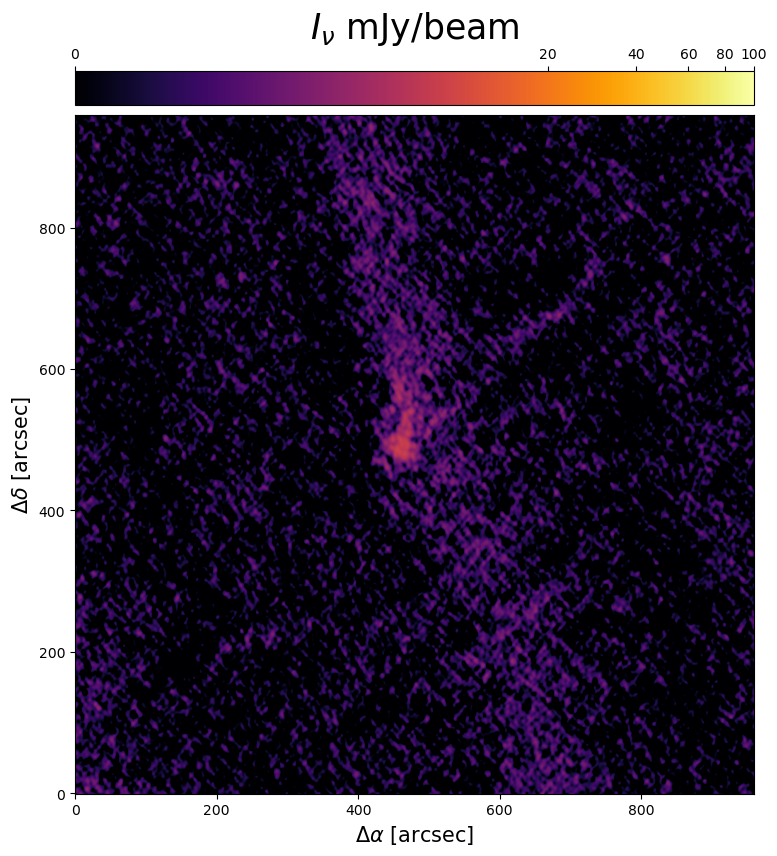

No valid patch input, skipping...


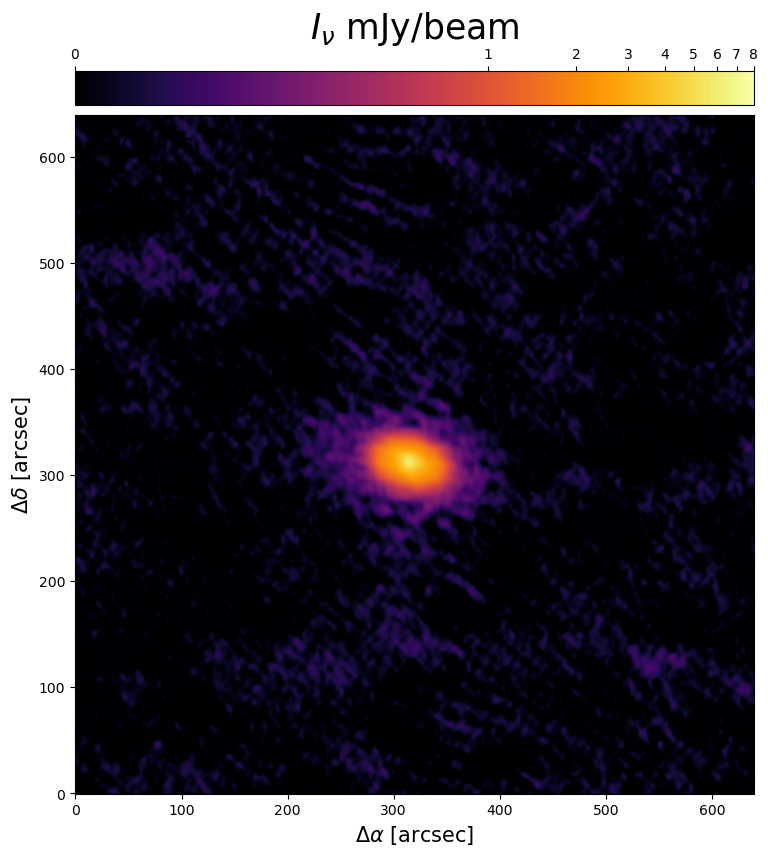

In [2]:
data = source_dict['member.uid___A001_X2d8_X4a.TMC1A_CO21.image']['data'][0]
header = source_dict['member.uid___A001_X2d8_X4a.TMC1A_CO21.image']['header']
cont_data = source_dict['member.uid___A001_X2d8_X4a.calibrated_final_cont_finalcontproduct.image']['data'].reshape(640,640)
cont_header =  source_dict['member.uid___A001_X2d8_X4a.calibrated_final_cont_finalcontproduct.image']['header']
import numpy as np
from tqdm import tqdm
# 12CO dataa shape 30, 960, 960
plot_image(data[12,:,:]*1000, header, vmin = -1e-5, vmax = 100, text= None, telescope= 'ALMA') # begin from channel 10 end at 24
plot_image(cont_data*1000, header = cont_header, vmin = -1e-5, vmax = 8, telescope= 'ALMA')


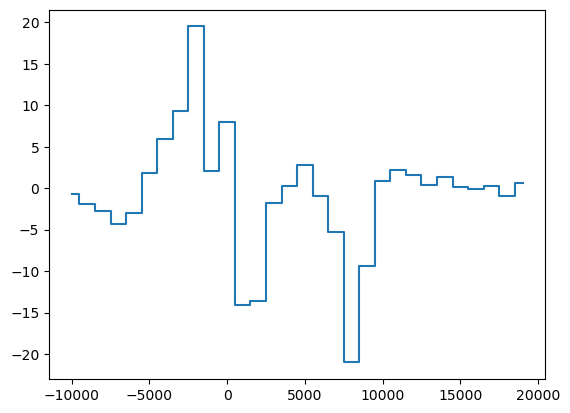

In [4]:
def radio_velocity( restfreq , freqls, c = 3e8):
    
    return (restfreq - freqls)/restfreq * c

data = source_dict['member.uid___A001_X2d8_X4a.TMC1A_CO21.image']['data'][0]
init_freq = header['CRVAL3']
n_freq = header['NAXIS3']
deltfreq = header['CDELT3']

pixel = abs(header['CDELT1']) * 3600
bmaj = header['BMAJ'] * 3600
bmin = header['BMIN'] * 3600

Jy_per_pix = (np.pi/(4*np.log(2)) * bmaj * bmin)/pixel
flux_ls = np.sum(data, axis = (1,2)) * Jy_per_pix
freqls = []
for i in range(n_freq):
    freqls.append(init_freq + i * deltfreq)

freqls = np.array(freqls)
CO_restfreq = 230.538e9 # unit in Hz, based on splatalogue

vel_LSRK = radio_velocity(CO_restfreq, freqls)
#print(vel_LSRK)

import matplotlib.pyplot as plt
fig = plt.figure()
plt.step(vel_LSRK, flux_ls, where = 'mid')
plt.show()


RMS = 0.80 mJy/beam (original)
velocity list [-1.00069229e+04 -9.00623065e+03 -8.00553837e+03 -7.00484608e+03
 -6.00415379e+03 -5.00346151e+03 -4.00276922e+03 -3.00207694e+03
 -2.00138465e+03 -1.00069237e+03 -8.10137930e-05  1.00069220e+03
  2.00138449e+03  3.00207678e+03  4.00276906e+03  5.00346135e+03
  6.00415363e+03  7.00484592e+03  8.00553820e+03  9.00623049e+03
  1.00069228e+04  1.10076151e+04  1.20083073e+04  1.30089996e+04
  1.40096919e+04  1.50103842e+04  1.60110765e+04  1.70117688e+04
  1.80124611e+04  1.90131533e+04]


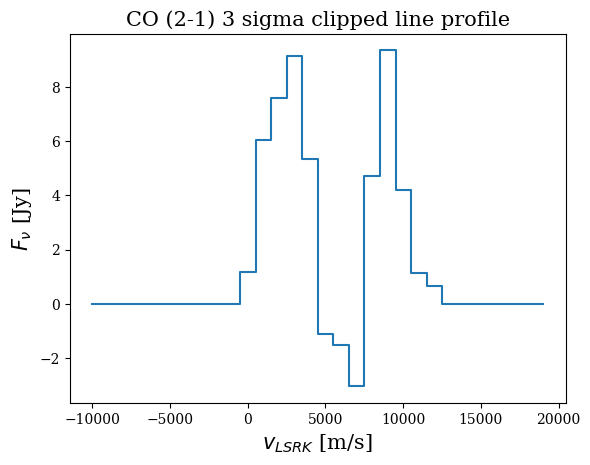

In [5]:
import bettermoments as bm
import matplotlib as mpl

mpl.rc('font', family='serif')
mpl.rc('axes', titlesize=15, labelsize=15)
# Generate Moment zero map of FeII 1.644 the continuum emission
filepath = '/media/kuo-jui/data/ISM_finalproject/data/ALMA_Band6'
os.chdir(filepath)


# Decide the moment map region [w1:w2]
line_data = source_dict['member.uid___A001_X2d8_X4a.TMC1A_CO21.image']['data'][0]
rms = bm.estimate_RMS(data = data, N = 6) # set it in a line free region
print('RMS = {:.2f} mJy/beam (original)'.format(rms *1000 ))


user_mask = bm.get_user_mask(data= line_data, user_mask_path= None)

threshold_mask = bm.get_threshold_mask(data= line_data,
                                       clip= 3,
                                       smooth_threshold_mask=0.0)

channel_mask = bm.get_channel_mask(data = line_data,
                                   firstchannel = 10,
                                   lastchannel = -8)

mask = bm.get_combined_mask(user_mask = user_mask, threshold_mask = threshold_mask, channel_mask = channel_mask, combine = 'and')
masked_data = line_data *mask

masked_flux = np.nansum(masked_data, axis = (1,2)) * (np.pi/(4*np.log(2)) * bmaj * bmin)/pixel
fig = plt.figure()
print('velocity list', vel_LSRK)
plt.step(vel_LSRK, masked_flux, where = 'mid')
plt.xlabel(r'$v_{LSRK}$' + ' [m/s]')
plt.ylabel(r'$F_\nu$' + ' [Jy]')
plt.title('CO (2-1) 3 sigma clipped line profile')
plt.show()
moments = bm.collapse_zeroth(velax= vel_LSRK, data= masked_data, rms = rms)
bm.save_to_FITS(moments = moments, method= 'zeroth', path= filepath+"/member.uid___A001_X2d8_X4a.TMC1A_CO21.image.fits", outname = 'TMC1A_CO21.3sigclip.fits')
#moments = bm.collapse_first(velax= vel_LSRK, data= masked_data, rms = rms)
#bm.save_to_FITS(moments = moments, method= 'first', path= filepath+"/member.uid___A001_X2d8_X4a.TMC1A_CO21.image.fits", outname = 'TMC1A_CO21.3sigclip.fits')



In [31]:
from matplotlib.colorbar import Colorbar
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.visualization import LogStretch, AsinhStretch, ImageNormalize
# Thee following testing is based on 3 sigma clipping result
ch0 = masked_data[12,300:660, 300:660]*1000
ch13 = masked_data[-10, 300:660, 300:660] * 1000 # mJy/beam

fig = plt.figure(figsize = (8,10))

widths = [0.05,1]
heights = [0.05,1]
gs = fig.add_gridspec(2, 2, width_ratios=widths,height_ratios=heights)
gs.update(left=0.05, right=0.95, bottom=0.08, top=0.85, wspace=0.02, hspace=0.02)
    
pixel = header['CDELT2']*3600  # arcsec/pixel
ax1 = fig.add_subplot(gs[1,1])
#divider1 = make_axes_locatable(ax1)
#cbar = divider1.append_axes("top", size="5%", pad=0.1)

# Change the ticks to arcsec
def axis_transfer(pos,val):
    return f'{ (pos-180) *pixel :.2f}'

ax1.contour(ch0, colors = 'blue')
ax1.contour(ch13, colors = 'red')

    
ax1.xaxis.set_major_formatter(FuncFormatter(axis_transfer))
ax1.yaxis.set_major_formatter(FuncFormatter(axis_transfer))
ax1.set_xlabel(r'$\Delta \alpha$' +' [arcsec]', fontsize = 15)
ax1.set_ylabel(r'$\Delta \delta$'+' [arcsec]',fontsize = 15)
ax1.text(0.05,0.95, s = 'CO 3km/s and 10km/s', transform = ax1.transAxes, fontsize = 15, color = 'black' )
#cbar.set_title(r'$I_\nu$'+ ' mJy/beam.km/s', fontsize = 25)
plt.show()

In [26]:
os.chdir(data_path + '/ALMA_Band6')
fitls = glob.glob('*.fits')
#print(fitls)
source_data = create_data_dict(fitls, check_header= True, check_file_header= 'TMC1A_CO21.5sigclip_M0.fits')
print(source_data.keys())

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  960                                                  
NAXIS2  =                  960                                                  
BMAJ    =   1.403301126427E-05                                                  
BMIN    =   9.601797080702E-06                                                  
BPA     =       21.91818618774                                                  
BUNIT   = 'Jy/beam m/s'                                                         
CTYPE1  = 'RA---SIN'                                                            
CRVAL1  =       69.89666666667                                                  
CDELT1  =             -1.5E-06                                                  
CRPIX1  =                481

Text(0.5, 1.0, '$I_\\nu$ mJy/beam.km/s')

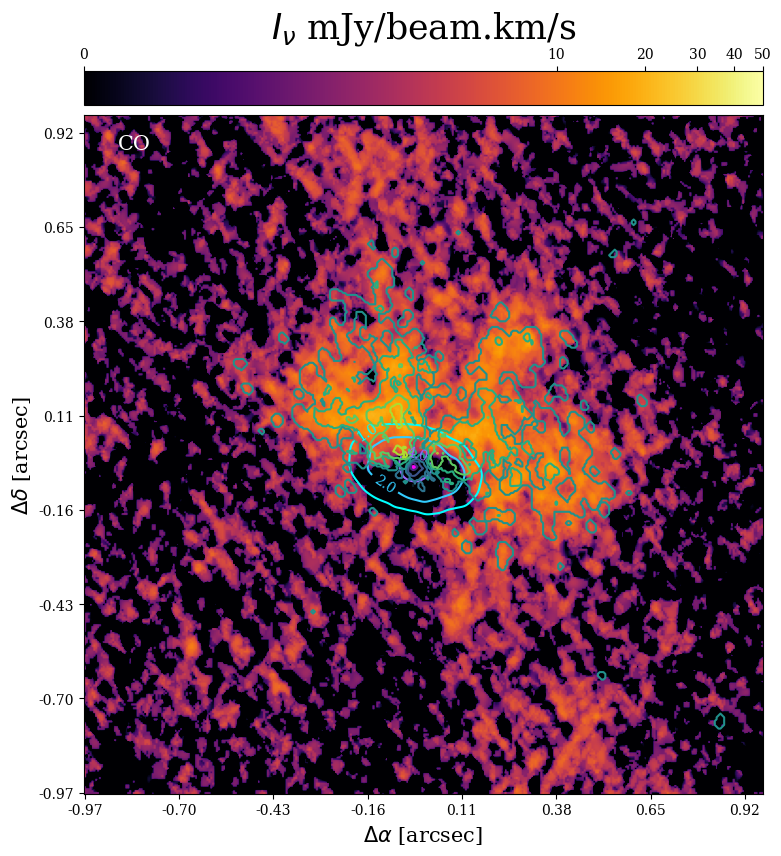

In [29]:
from matplotlib.colorbar import Colorbar
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.visualization import LogStretch, AsinhStretch, ImageNormalize

data = source_data['TMC1A_CO21.1.5sigclip_M0']['data']  # unit in mJy
header =  source_data['TMC1A_CO21.1.5sigclip_M0']['header']
data_5sig = source_data['TMC1A_CO21.5sigclip_M0']['data']
fig = plt.figure(figsize = (8,10))

widths = [0.05,1]
heights = [0.05,1]
gs = fig.add_gridspec(2, 2, width_ratios=widths,height_ratios=heights)
gs.update(left=0.05, right=0.95, bottom=0.08, top=0.85, wspace=0.02, hspace=0.02)
    
pixel = header['CDELT2']*3600  # arcsec/pixel
ax1 = fig.add_subplot(gs[1,1])
divider1 = make_axes_locatable(ax1)
cbar = divider1.append_axes("top", size="5%", pad=0.1)

# Change the ticks to arcsec
def axis_transfer(pos,val):
    return f'{ (pos-180) *pixel :.2f}'

norm1 = ImageNormalize(data[300:660, 300:660], vmin= -1e-5, vmax = 5e1, stretch = AsinhStretch(a = 1e-2)) # 5sig: 360:600
plt1 = ax1.imshow(data[300:660, 300:660], origin='lower', norm = norm1, cmap='inferno')
CS = ax1.contour(cont_data[140:500, 140:500], levels = [1e-3, 2e-3,4e-3,6e-3], cmap = 'cool')
ax1.clabel(CS, fontsize=10, fmt= lambda x: f'{x*1000:.1f}')
ax1.contour(data_5sig[300:660, 300:660], color = 'lime')
cb1 = Colorbar(ax = cbar, mappable = plt1, orientation = 'horizontal', ticklocation = 'top')
    
ax1.xaxis.set_major_formatter(FuncFormatter(axis_transfer))
ax1.yaxis.set_major_formatter(FuncFormatter(axis_transfer))
ax1.set_xlabel(r'$\Delta \alpha$' +' [arcsec]', fontsize = 15)
ax1.set_ylabel(r'$\Delta \delta$'+' [arcsec]',fontsize = 15)
ax1.text(0.05,0.95, s = 'CO', transform = ax1.transAxes, fontsize = 15, color = 'white' )
cbar.set_title(r'$I_\nu$'+ ' mJy/beam.km/s', fontsize = 25)

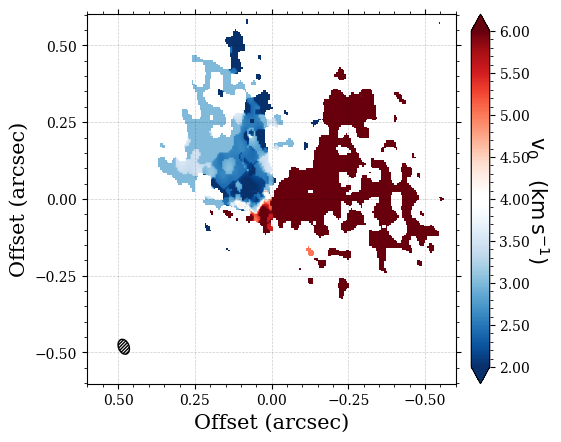

In [44]:
data = source_data['TMC1A_CO21.5sigclip_M1']['data']
uncern_data  =source_data['TMC1A_CO21.5sigclip_dM1']['data']
header =  source_data['TMC1A_CO21.5sigclip_M0']['header']

import eddy
from eddy import rotationmap

cube = rotationmap(path= 'TMC1A_CO21.5sigclip_M1.fits',
                   uncertainty= 'TMC1A_CO21.5sigclip_dM1.fits',
                   downsample=None,
                   FOV = 1.2
                   )

cube.plot_data(vmin = 2, vmax = 6)